# Data Analysis Graph

This notebook implements a LangGraph workflow for data analysis using AI agents.

## Setup and Configuration

In [25]:
# Import required libraries
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent.parent.parent
sys.path.insert(0, str(project_root))

# Import settings
from src.config import settings

print(f"Application: {settings.app_name}")
print(f"Version: {settings.app_version}")
print(f"Default LLM Model: {settings.default_llm_model}")
print(f"Temperature: {settings.default_llm_temperature}")


Application: Data Agent LangGraph
Version: 0.1.0
Default LLM Model: gpt-4o
Temperature: 0.7


## Import Dependencies

In [26]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import pandas as pd
import numpy as np
from typing import Any, Optional, List

## State definition

In [27]:
# create custom reducers

from typing import Dict


def reduce_search_payload(left: Dict[str,str] | None, right: Dict[str,str] | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = {}
    if not right:
        right={}
        
    left_copy=left.copy()
    
    left_copy.update(right)
        
    return left_copy


In [28]:
from typing import Dict
from src.graphs.custom_reducers.reduce_search_payload import reduce_search_payload
from src.graphs.state_definitions.overall_state import SearchPayload

class OverallState(TypedDict):
    messages: Annotated[list, add_messages]
    intent: Optional[str]
    search_attributes: Optional[list[str]]
    search_payload: Annotated[SearchPayload,reduce_search_payload]

## Init LLM

In [29]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=settings.default_llm_model, 
    temperature=settings.default_llm_temperature,
    api_key=settings.openai_api_key
)

## Intent classification node

In [30]:

from typing import Literal
from pydantic import BaseModel, Field
from src.graphs.prompts.intent_classification import INTENT_CLASSIFICATION_PROMPT

class IntentClassificationOutput(BaseModel):
    intent: Literal["search", "document_accuracy", "document_counter", "document_processing_time", "others"] = Field(
        ..., 
        description="The user's intent based on the conversation."
    )    
    reasoning: str = Field(..., description="The reasoning behind the intent classification.")


def intent_classifier(state: OverallState):
    print("\n 🟢 I am in intent classifier node")
    
    structured_llm = llm.with_structured_output(IntentClassificationOutput)
    
    output = structured_llm.invoke([SystemMessage(content=INTENT_CLASSIFICATION_PROMPT)] + state["messages"])
    
    print("llm_output: ", output)
    
    return {"intent": output.intent,"messages":[AIMessage(content=output.reasoning)]}

## Request user input for edge cases:

In [31]:
def user_input_clarity(state:OverallState):
    pass

## Conditional routing for intent

In [32]:

def routing_intent(state: OverallState):
    print("\n ⭐ I am in routing intent")
    
    if state['intent'] in ["document_accuracy", "document_counter", "document_processing_time"]:
        print("routing business parameters intent")
        return "document parameters intent"
    
    if state['intent'] == 'others':
        # human in the loop ask user to input again
        print("intent is unclear, request user query refinement")
        return "unclear intent"
    
    print("routing to search intent")
    return "search intent"

## Extract search attrbutes node for search query

In [33]:
from src.graphs.prompts.search_attributes_extraction import SEARCH_ATTRIBUTES_EXTRACTION_PROMPT

# Pydantic model for LLM response
class AttributesExtraction(BaseModel):
    """Classification of user intent"""
    attributes: List[Literal["document_model", "queue", "date"]] = Field(
        description="The attributes that need to be extracted. Must only contain: document model, queue, or date"
    )
    reasoning: str


# Node 2: Search Node (placeholder)
def extract_search_attributes_from_query(state: OverallState) -> dict:
    """Placeholder search node - empty for now"""
    
    print("\n 🍿 I am in extracing search attributes from query node")
    
    # Use structured output with Pydantic
    structured_llm = llm.with_structured_output(AttributesExtraction)
    
    messages = [SystemMessage(content=SEARCH_ATTRIBUTES_EXTRACTION_PROMPT)] + state['messages']
    
    result: AttributesExtraction = structured_llm.invoke(messages)
    
    print("extracted attributed result: ",result)
    
    if not result.attributes:
        print("There are no valid attributes can be extracted from your query")
    else:
        print(f"Valid extracted attributes: {', '.join(result.attributes)}")
    
    
    return {
        "search_attributes": result.attributes,
        "messages":[AIMessage(content=result.reasoning)]
    }

## Conditional routing for extracted search query 

In [34]:
def routing_extracted_search_attributes(state: OverallState):
    print("\n 🍺 I am in routing extracted search attributes")
    
    search_attributes=state['search_attributes']
    
    if not search_attributes:
        print("There are no valid search attributes")
        print("request user query refinement")
        return "vague search query"
    
    print("valid search query => routing to processing search attributes")
    return "valid search query"

## Routing processing search attributes

In [35]:

def router_processing_search_attributes(state: OverallState):
    return {}

def routing_processing_search_attributes(state: OverallState):
    print("\n 🔥 I am in routing processing search attributes")
    
    search_attributes=state['search_attributes']
    
    if not search_attributes:
        print("complete all processing")
        return "complete processing"
    
    if "queue" in search_attributes:
        print("routing to queue processing sub graph")
        return "processing queue attribute"
    
    if "document_model" in search_attributes:
        print("routing to document model processing sub graph")
        return "processing document model attribute"
    

## Processing Search Attribute Node

In [36]:
def processing_queue_search_attribute_node(state: OverallState):
    return {}

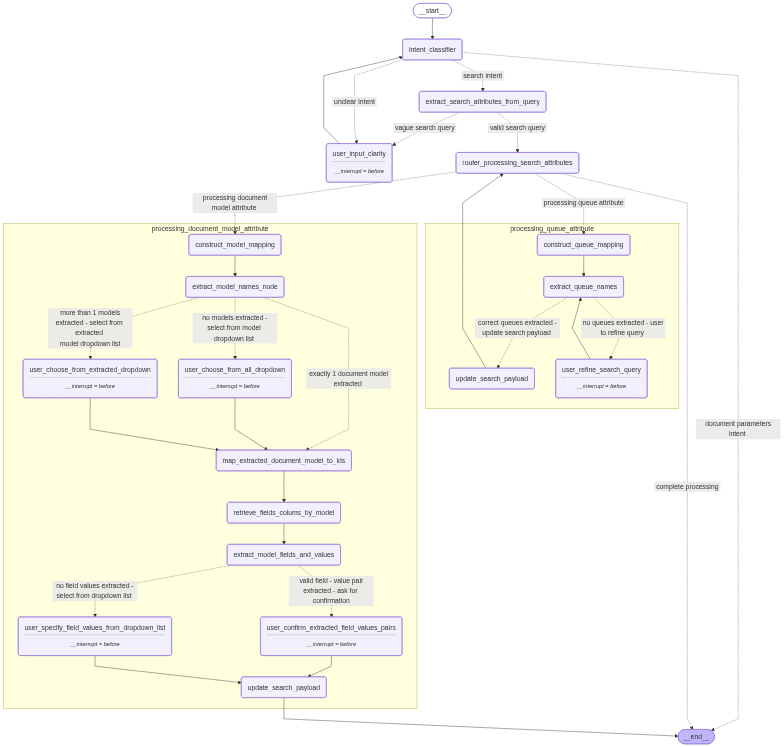

In [37]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from src.graphs.sub_graphs.queue_processing_graph import create_queue_processing_graph
from src.graphs.sub_graphs.document_model_processing_graph import create_document_model_processing_graph
  
memory = MemorySaver()

test_builder=StateGraph(OverallState)

test_builder.add_node("intent_classifier",intent_classifier)
test_builder.add_node("user_input_clarity",user_input_clarity)
test_builder.add_node("extract_search_attributes_from_query",extract_search_attributes_from_query)
test_builder.add_node("router_processing_search_attributes",router_processing_search_attributes)
test_builder.add_node("processing_queue_attribute",create_queue_processing_graph(llm=llm,checkpointer=memory))
test_builder.add_node("processing_document_model_attribute",create_document_model_processing_graph(llm=llm,checkpointer=memory))


test_builder.add_edge(START,"intent_classifier")
test_builder.add_conditional_edges("intent_classifier", 
                                   routing_intent, 
                                   {"unclear intent":"user_input_clarity", 
                                    "search intent":"extract_search_attributes_from_query",
                                    "document parameters intent":END}
                                   )
test_builder.add_edge("user_input_clarity","intent_classifier")
test_builder.add_conditional_edges("extract_search_attributes_from_query", 
                                   routing_extracted_search_attributes, 
                                   {"vague search query":"user_input_clarity",
                                    "valid search query":"router_processing_search_attributes"})
test_builder.add_conditional_edges("router_processing_search_attributes", 
                                   routing_processing_search_attributes, 
                                   {"processing queue attribute":"processing_queue_attribute",
                                    "processing document model attribute":"processing_document_model_attribute",
                                    "complete processing":END})
test_builder.add_edge("processing_queue_attribute","router_processing_search_attributes")


# Compile
graph = test_builder.compile(interrupt_before=["user_input_clarity"],checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [38]:
# graph.invoke({"messages": [HumanMessage(content="I want to search all documents from queue xyz from 1/11/2025 to now and from invoice model")]})

# graph.invoke({"messages": [HumanMessage(content="I want to know the document processing time")]})
thread = {"configurable": {"thread_id": "3"}}

# graph.invoke({"messages": [HumanMessage(content="I wanna search documents belong to queues containing Louis")]},thread)
graph.invoke({"messages": [HumanMessage(content="I wanna search documents with queue containing Josh from invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank ")]},thread)


 🟢 I am in intent classifier node
llm_output:  intent='search' reasoning='The user is requesting to search for documents with specific criteria, including a queue containing a specific name, using an invoice model, and filtering by specific invoice number, date, and customer name.'

 ⭐ I am in routing intent
routing to search intent

 🍿 I am in extracing search attributes from query node
extracted attributed result:  attributes=['document_model'] reasoning="The user wants to search for documents with a specific document type, 'invoice model'. The mention of 'queue containing Josh' suggests a search by queue, but 'Josh' is not a standard queue name. Other details like invoice number, date, and customer name are specific document fields, not the provided search attributes."
Valid extracted attributes: document_model

 🍺 I am in routing extracted search attributes
valid search query => routing to processing search attributes

 🔥 I am in routing processing search attributes
routing to doc

{'messages': [HumanMessage(content='I wanna search documents with queue containing Josh from invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank ', additional_kwargs={}, response_metadata={}, id='558b98f6-75c3-445a-b002-7862c18ff5f7'),
  AIMessage(content='The user is requesting to search for documents with specific criteria, including a queue containing a specific name, using an invoice model, and filtering by specific invoice number, date, and customer name.', additional_kwargs={}, response_metadata={}, id='1ba5fc67-964a-41ba-9dee-616b82c6ff37'),
  AIMessage(content="The user wants to search for documents with a specific document type, 'invoice model'. The mention of 'queue containing Josh' suggests a search by queue, but 'Josh' is not a standard queue name. Other details like invoice number, date, and customer name are specific document fields, not the provided search attributes.", additional_kwargs={}, response_metada

In [39]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='I wanna search documents with queue containing Josh from invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank ', additional_kwargs={}, response_metadata={}, id='558b98f6-75c3-445a-b002-7862c18ff5f7'), AIMessage(content='The user is requesting to search for documents with specific criteria, including a queue containing a specific name, using an invoice model, and filtering by specific invoice number, date, and customer name.', additional_kwargs={}, response_metadata={}, id='1ba5fc67-964a-41ba-9dee-616b82c6ff37'), AIMessage(content="The user wants to search for documents with a specific document type, 'invoice model'. The mention of 'queue containing Josh' suggests a search by queue, but 'Josh' is not a standard queue name. Other details like invoice number, date, and customer name are specific document fields, not the provided search attributes.", additional_kwargs={}

In [40]:
state.next

('processing_document_model_attribute',)

In [41]:
main_state = graph.get_state(thread)
main_state.tasks

(PregelTask(id='c6add442-16ba-8d52-62fd-88710141a9e7', name='processing_document_model_attribute', path=('__pregel_pull', 'processing_document_model_attribute'), error=None, interrupts=(), state={'configurable': {'thread_id': '3', 'checkpoint_ns': 'processing_document_model_attribute:c6add442-16ba-8d52-62fd-88710141a9e7'}}, result=None),)

In [42]:
main_state = graph.get_state(thread)
subgraph_task = main_state.tasks[0]  # Get the first task
subgraph_checkpoint_config = subgraph_task.state  # This has the subgraph's checkpoint info

In [43]:
subgraph_checkpoint_config

{'configurable': {'thread_id': '3',
  'checkpoint_ns': 'processing_document_model_attribute:c6add442-16ba-8d52-62fd-88710141a9e7'}}

In [44]:
subgraph_state = graph.get_state(subgraph_checkpoint_config)
subgraph_state.next

('user_confirm_extracted_field_values_pairs',)

In [45]:
graph.invoke(None,thread)


 🚀 I am in update_search_payload node


{'messages': [HumanMessage(content='I wanna search documents with queue containing Josh from invoice model with Invoice number is 34ictgh789 and Invoice date is 25th November 2025 and Customer Name is DBS Bank ', additional_kwargs={}, response_metadata={}, id='558b98f6-75c3-445a-b002-7862c18ff5f7'),
  AIMessage(content='The user is requesting to search for documents with specific criteria, including a queue containing a specific name, using an invoice model, and filtering by specific invoice number, date, and customer name.', additional_kwargs={}, response_metadata={}, id='1ba5fc67-964a-41ba-9dee-616b82c6ff37'),
  AIMessage(content="The user wants to search for documents with a specific document type, 'invoice model'. The mention of 'queue containing Josh' suggests a search by queue, but 'Josh' is not a standard queue name. Other details like invoice number, date, and customer name are specific document fields, not the provided search attributes.", additional_kwargs={}, response_metada

In [46]:
main_state = graph.get_state(thread)
main_state.tasks

()

In [47]:
main_state = graph.get_state(thread)
subgraph_task = main_state.tasks[0]  # Get the first task
subgraph_checkpoint_config = subgraph_task.state  # This has the subgraph's checkpoint info

IndexError: tuple index out of range

In [ ]:
subgraph_checkpoint_config

{'configurable': {'thread_id': '3',
  'checkpoint_ns': 'processing_document_model_attribute:540ce93b-c542-ecb7-43ad-35b5acb22565'}}

In [ ]:
subgraph_state = graph.get_state(subgraph_checkpoint_config)
subgraph_state.next

('user_choose_from_all_dropdown',)

In [ ]:
# Update the SUBGRAPH's state
graph.update_state(
      subgraph_checkpoint_config,  # Use subgraph's config, not main thread
)


 🚀 I am in routing_based_on_extracted_documents_models
extracted_documents_models:  []
there are no valid document models in user query


{'configurable': {'thread_id': '3',
  'checkpoint_ns': 'processing_document_model_attribute:540ce93b-c542-ecb7-43ad-35b5acb22565',
  'checkpoint_id': '1f0d43a8-492b-6c44-8003-beec1d0d0a6b',
  'checkpoint_map': {'': '1f0d43a8-33a8-6db8-8006-7b6edeb899e0',
   'processing_document_model_attribute:540ce93b-c542-ecb7-43ad-35b5acb22565': '1f0d43a8-492b-6c44-8003-beec1d0d0a6b'}}}

In [ ]:
graph.invoke(None,thread)


 🚀 I am in map_extracted_document_model_to_ids


KeyError: 'model'